## This File is to start making/ testing/ trying different models for misinformation detection at the claim level

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support, f1_score
from sklearn.svm import LinearSVC
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import torch.nn.functional as F
from transformers import AutoTokenizer

In [2]:
# read in csv of data from dataGathering.ipynb
combined = pd.read_csv("combinedClaimDataset.csv")
combined.head()

,claim,label,source
0,Nikolaj Coster-Waldau worked with the Fox Broa...,supported,fever
1,Roman Atwood is a content creator.,supported,fever
2,"History of art includes architecture, dance, s...",supported,fever
3,Adrienne Bailon is an accountant.,refuted,fever
4,System of a Down briefly disbanded in limbo.,not_enough_info,fever


In [3]:
# Recreate per-source dataframes
fever_df    = combined[combined['source'] == 'fever'].copy()
liar_df     = combined[combined['source'] == 'liar'].copy()
scifact_df  = combined[combined['source'] == 'scifact'].copy()

for name, df in [('FEVER', fever_df), ('LIAR', liar_df), ('SciFact', scifact_df)]:
    print(name, df['label'].value_counts(), '\n')

FEVER label
supported          77054
not_enough_info    36814
refuted            31419
Name: count, dtype: int64 

LIAR label
not_enough_info    4723
supported          4502
refuted            3540
Name: count, dtype: int64 

SciFact label
supported    455
refuted      237
Name: count, dtype: int64 



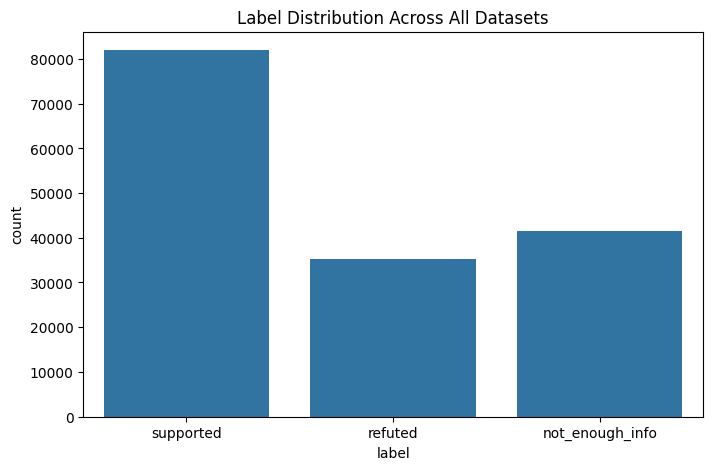

Label counts:
label
supported          82011
not_enough_info    41537
refuted            35196
Name: count, dtype: int64 



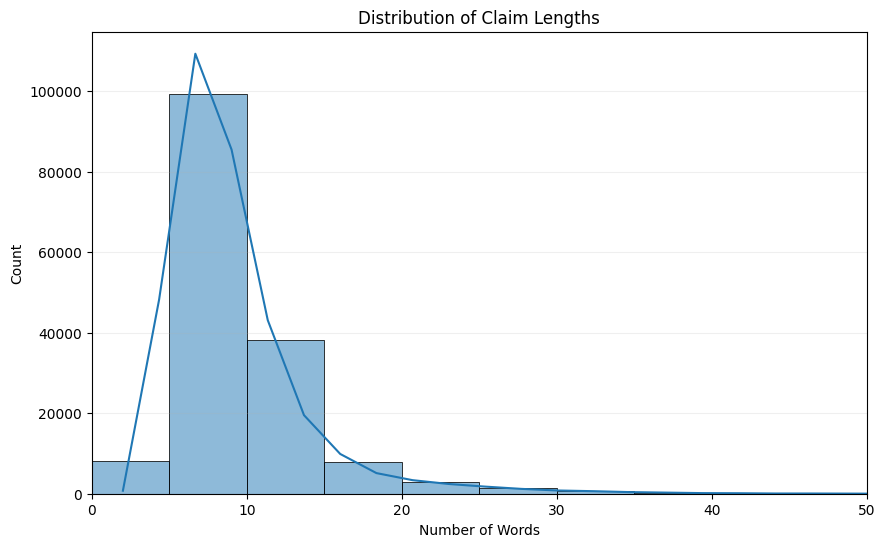

Length stats:
count    158744.000000
mean          8.980447
std           4.898741
min           2.000000
25%           6.000000
50%           8.000000
75%          10.000000
max         467.000000
Name: length, dtype: float64 



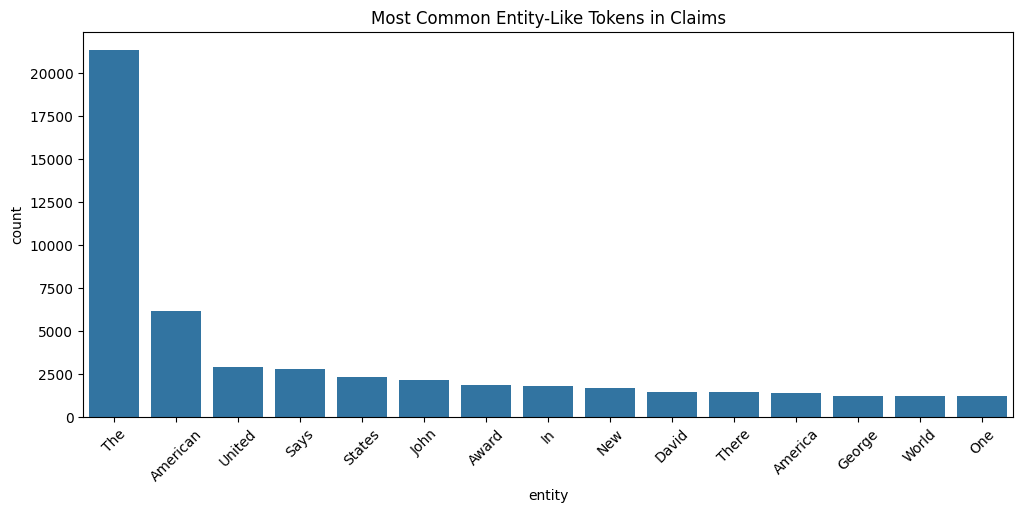

Top 20 entity-like tokens:
         entity  count
26          The  21304
15     American   6191
55       United   2900
14580      Says   2821
56       States   2318
67         John   2162
376       Award   1892
698          In   1818
37          New   1661
223       David   1451
42        There   1450
183     America   1375
475      George   1249
587       World   1248
158         One   1241
57      Michael   1234
340     Academy   1202
203          TV   1178
1757      Obama   1127
384       James   1107 

Vocabulary Overlap:
FEVER vs LIAR: 0.17981054444550762
FEVER vs SciFact: 0.027875340093989613
LIAR vs SciFact: 0.039363621453173694


In [4]:
full_df = combined.copy()

# Label distribution
plt.figure(figsize=(8,5))
sns.countplot(data=full_df, x='label', order=['supported','refuted','not_enough_info'])
plt.title("Label Distribution Across All Datasets")
plt.show()

print("Label counts:")
print(full_df['label'].value_counts(), "\n")

# Claim length distribution
full_df['length'] = full_df['claim'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))
bins = np.arange(0,105,5)
sns.histplot(full_df['length'], bins=bins, kde=True)
plt.title("Distribution of Claim Lengths")
plt.xlabel("Number of Words")
plt.xlim(0,50)
plt.grid(axis='y', alpha= .2)
plt.show()

print("Length stats:")
print(full_df['length'].describe(), "\n")

# Entity analysis
def extract_simple_entities(text):
    ents = []
    
    # Capitalized words (names, places, organizations)
    ents += re.findall(r"\b[A-Z][a-z]+\b", text)
    
    # Acronyms (NASA, WHO, CDC)
    ents += re.findall(r"\b[A-Z]{2,}\b", text)
    
    # Years (4-digit numbers)
    ents += re.findall(r"\b\d{4}\b", text)
    
    # Hyphenated scientific terms
    ents += re.findall(r"\b\w+-\w+\b", text)
    
    return ents

full_df['entities'] = full_df['claim'].apply(extract_simple_entities)

all_entities = [ent for sublist in full_df['entities'] for ent in sublist]
entity_counts = Counter(all_entities)

entity_df = pd.DataFrame(entity_counts.items(), columns=['entity','count']).sort_values('count', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(data=entity_df.head(15), x='entity', y='count')
plt.title("Most Common Entity-Like Tokens in Claims")
plt.xticks(rotation=45)
plt.show()

print("Top 20 entity-like tokens:")
print(entity_df.head(20), "\n")

# Vocab overlap
def get_vocab(df):
    vocab = set()
    for text in df['claim']:
        for word in text.lower().split():
            vocab.add(word)
    return vocab

fever_vocab = get_vocab(fever_df)
liar_vocab = get_vocab(liar_df)
scifact_vocab = get_vocab(scifact_df)

def jaccard(a, b):
    return len(a & b) / len(a | b)

print("Vocabulary Overlap:")
print("FEVER vs LIAR:", jaccard(fever_vocab, liar_vocab))
print("FEVER vs SciFact:", jaccard(fever_vocab, scifact_vocab))
print("LIAR vs SciFact:", jaccard(liar_vocab, scifact_vocab))

In [5]:
# # Train/validate/test split function to split the datasets to ensure one source doesnt get misrepresented.
# def split_dataset(df, name):
#     train, temp = train_test_split(
#         df,
#         test_size=0.50,
#         stratify=df['label'],
#         random_state=42
#     )
#     val, test = train_test_split(
#         temp,
#         test_size=0.50,
#         stratify=temp['label'],
#         random_state=42
#     )
#     print(f"{name} shapes -> train: {train.shape}, val: {val.shape}, test: {test.shape}")
#     return train, val, test

# fever_train, fever_val, fever_test       = split_dataset(fever_df,   "FEVER")
# liar_train, liar_val, liar_test          = split_dataset(liar_df,    "LIAR")
# scifact_train, scifact_val, scifact_test = split_dataset(scifact_df, "SciFact")

# train_df = pd.concat([fever_train, liar_train, scifact_train], ignore_index=True)
# val_df   = pd.concat([fever_val,   liar_val,   scifact_val],   ignore_index=True)
# test_df  = pd.concat([fever_test,  liar_test,  scifact_test],  ignore_index=True)

# for name, df in [('TRAIN', train_df), ('VAL', val_df), ('TEST', test_df)]:
#     print(name, df['label'].value_counts(), '\n')

In [6]:
# # Building and testing a logistic regression model for baseline performance
# X_train, y_train = train_df['claim'], train_df['label']
# X_val,   y_val   = val_df['claim'],   val_df['label']
# X_test,  y_test  = test_df['claim'],  test_df['label']

# tfidf_logreg = Pipeline([
#     ("tfidf", TfidfVectorizer(
#         ngram_range=(1,2),
#         max_features=100_000,
#         min_df=2
#     )),
#     # ("clf", LogisticRegression
#         max_iter=10_000,
#         class_weight="balanced",
#         n_jobs=-1
#     ))
# ])

# tfidf_logreg.fit(X_train, y_train)

# print("Validation performance (LogReg):")
# y_val_pred = tfidf_logreg.predict(X_val)
# print(classification_report(y_val, y_val_pred))

# print("Test performance (LogReg):")
# y_test_pred = tfidf_logreg.predict(X_test)
# print(classification_report(y_test, y_test_pred))
# print("Confusion matrix (test):")
# print(confusion_matrix(y_test, y_test_pred, labels=['supported','refuted','not_enough_info']))

In [7]:
# # Building and testing an SVM model for more baseline performance
# tfidf_svm = Pipeline([
#     ("tfidf", TfidfVectorizer(
#         ngram_range=(1,2),
#         max_features=100_000,
#         min_df=2
#     )),
#     ("clf", LinearSVC(class_weight="balanced"))
# ])

# tfidf_svm.fit(X_train, y_train)

# print("Validation performance (SVM):")
# y_val_pred = tfidf_svm.predict(X_val)
# print(classification_report(y_val, y_val_pred))

# print("Test performance (SVM):")
# y_test_pred = tfidf_svm.predict(X_test)
# print(classification_report(y_test, y_test_pred))
# print("Confusion matrix (test):")
# print(confusion_matrix(y_test, y_test_pred, labels=['supported','refuted','not_enough_info']))

## Attempt two at improving performance by using contrastive cross domain training

In [5]:
TARGET_FEVER_SIZE = 60000

if len(fever_df) > TARGET_FEVER_SIZE:
    frac = TARGET_FEVER_SIZE / len(fever_df)

    fever_df_small = (
        fever_df
        .groupby("label", group_keys=False)
        .sample(frac=frac, random_state=42)
        .reset_index(drop=True)
    )
else:
    fever_df_small = fever_df.copy()

In [6]:
# Resplitting dataset with downsampled fever dataset
def split_dataset(df, name):
    train, temp = train_test_split(
        df,
        test_size=0.50,
        stratify=df["label"],
        random_state=42
    )
    val, test = train_test_split(
        temp,
        test_size=0.50,
        stratify=temp["label"],
        random_state=42
    )
    print(f"{name} shapes -> train: {train.shape}, val: {val.shape}, test: {test.shape}")
    return train, val, test

fever_train, fever_val, fever_test       = split_dataset(fever_df_small, "FEVER")
liar_train, liar_val, liar_test          = split_dataset(liar_df,        "LIAR")
scifact_train, scifact_val, scifact_test = split_dataset(scifact_df,     "SciFact")

train_df = pd.concat([fever_train, liar_train, scifact_train], ignore_index=True)
val_df   = pd.concat([fever_val,   liar_val,   scifact_val],   ignore_index=True)
test_df  = pd.concat([fever_test,  liar_test,  scifact_test],  ignore_index=True)

for name, df in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    print(name, df["label"].value_counts(), "\n")

FEVER shapes -> train: (29999, 3), val: (15000, 3), test: (15000, 3)
LIAR shapes -> train: (6382, 3), val: (3191, 3), test: (3192, 3)
SciFact shapes -> train: (346, 3), val: (173, 3), test: (173, 3)
TRAIN label
supported          18389
not_enough_info     9962
refuted             8376
Name: count, dtype: int64 

VAL label
supported          9194
not_enough_info    4982
refuted            4188
Name: count, dtype: int64 

TEST label
supported          9195
not_enough_info    4982
refuted            4188
Name: count, dtype: int64 



In [7]:
# mapping labels to integers for BERT model
label_map = {
    "supported": 0,
    "refuted": 1,
    "not_enough_info": 2
}

train_df["label"] = train_df["label"].map(label_map)
val_df["label"]   = val_df["label"].map(label_map)
test_df["label"]  = test_df["label"].map(label_map)

# Map source/domain
domain_map = {
    "fever": 0,
    "liar": 1,
    "scifact": 2
}

train_df["domain"] = train_df["source"].map(domain_map)
val_df["domain"]   = val_df["source"].map(domain_map)
test_df["domain"]  = test_df["source"].map(domain_map)

# Build lists
train_texts   = train_df["claim"].tolist()
train_labels  = train_df["label"].tolist()
train_domains = train_df["domain"].tolist()

val_texts   = val_df["claim"].tolist()
val_labels  = val_df["label"].tolist()
val_domains = val_df["domain"].tolist()

test_texts   = test_df["claim"].tolist()
test_labels  = test_df["label"].tolist()
test_domains = test_df["domain"].tolist()

print("Train label distribution:", pd.Series(train_labels).value_counts())
print("Train domain distribution:", pd.Series(train_domains).value_counts())

Train label distribution: 0    18389
2     9962
1     8376
Name: count, dtype: int64
Train domain distribution: 0    29999
1     6382
2      346
Name: count, dtype: int64


In [ ]:
# # data loader for BERT model
# tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
# class ClaimDataset(Dataset):
#     def __init__(self, texts, labels, domains, tokenizer, max_length=64):
#         self.texts = texts
#         self.labels = labels
#         self.domains = domains
#         self.tokenizer = tokenizer
#         self.max_length = max_length

#     def __len__(self):
#         return len(self.texts)

#     def __getitem__(self, idx):
#         encoding = self.tokenizer(
#             self.texts[idx],
#             truncation=True,
#             padding="max_length",
#             max_length=self.max_length,
#             return_tensors="pt"
#         )
#         item = {key: val.squeeze(0) for key, val in encoding.items()}
#         item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
#         item["domains"] = torch.tensor(self.domains[idx], dtype=torch.long)
#         return item

# train_dataset = ClaimDataset(train_texts, train_labels, train_domains, tokenizer)
# val_dataset   = ClaimDataset(val_texts,   val_labels,   val_domains,   tokenizer)
# test_dataset  = ClaimDataset(test_texts,  test_labels,  test_domains,  tokenizer)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
# test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [ ]:
# id2label = {0: "supported", 1: "refuted", 2: "not_enough_info"}
# label2id = {"supported": 0, "refuted": 1, "not_enough_info": 2}

# device = torch.device("cpu")
# torch.set_num_threads(4)

# model_name = "microsoft/deberta-v3-base"

# model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=3,
#     id2label=id2label,
#     label2id=label2id,
#     problem_type="single_label_classification",
#     output_hidden_states=True  # needed for contrastive embeddings
# ).to(device)

# # Class weights
# class_weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.array([0, 1, 2]),
#     y=np.array(train_labels)
# )
# weights = torch.tensor(class_weights, dtype=torch.float).to(device)
# ce_loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

# # Projection head for contrastive learning
# proj_dim = 384
# hidden_size = model.config.hidden_size  # 768 for DistilBERT

# projection_head = torch.nn.Sequential(
#     torch.nn.Linear(hidden_size, hidden_size),
#     torch.nn.ReLU(),
#     torch.nn.Linear(hidden_size, proj_dim)
# ).to(device)

# # Optimizer & scheduler
# num_epochs = 3
# optimizer = AdamW(
#     list(model.parameters()) + list(projection_head.parameters()),
#     lr=2e-5
# )

# num_training_steps = num_epochs * len(train_loader)
# scheduler = get_linear_schedule_with_warmup(
#     optimizer,
#     num_warmup_steps=int(0.1 * num_training_steps),
#     num_training_steps=num_training_steps
# )


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight        

In [ ]:
# def supervised_contrastive_loss(embeddings, labels, domains, temperature=0.1):
#     device = embeddings.device
#     batch_size = embeddings.size(0)

#     # Normalize embeddings
#     embeddings = F.normalize(embeddings, p=2, dim=1)

#     # Compute similarity matrix
#     sim_matrix = torch.matmul(embeddings, embeddings.T) / temperature  # [B, B]

#     # Mask out self-similarity
#     mask = torch.eye(batch_size, dtype=torch.bool, device=device)
#     sim_matrix = sim_matrix.masked_fill(mask, -1e9)

#     labels = labels.view(-1, 1)
#     domains = domains.view(-1, 1)

#     # Positive mask: same label, different domain
#     same_label = (labels == labels.T)
#     diff_domain = (domains != domains.T)
#     pos_mask = same_label & diff_domain

#     # If no cross-domain positive exists for some anchor, fall back to same label
#     fallback_pos_mask = same_label & ~diff_domain
#     effective_pos_mask = torch.where(
#         pos_mask.any(dim=1, keepdim=True),
#         pos_mask,
#         fallback_pos_mask
#     )

#     # For each anchor, compute log-softmax over all others
#     log_prob = F.log_softmax(sim_matrix, dim=1)

#     # Only keep positives
#     pos_log_prob = (log_prob * effective_pos_mask).sum(dim=1) / effective_pos_mask.sum(dim=1).clamp(min=1)

#     loss = -pos_log_prob.mean()
#     return loss


In [ ]:
# def evaluate(model, projection_head, dataloader, ce_loss_fn, lambda_contrastive=0.01):
#     model.eval()
#     projection_head.eval()

#     total_loss = 0.0
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for batch in dataloader:
#             batch = {k: v.to(device) for k, v in batch.items()}

#             outputs = model(
#                 input_ids=batch["input_ids"],
#                 attention_mask=batch["attention_mask"],
#                 labels=batch["labels"]
#             )

#             ce_loss = ce_loss_fn(outputs.logits, batch["labels"])

#             # Contrastive part
#             cls_embeddings = outputs.hidden_states[-1][:, 0, :]  # [B, H]
#             proj = projection_head(cls_embeddings)               # [B, proj_dim]
#             cont_loss = supervised_contrastive_loss(
#                 proj,
#                 batch["labels"],
#                 batch["domains"]
#             )

#             loss = ce_loss + lambda_contrastive * cont_loss
#             total_loss += loss.item()

#             preds = outputs.logits.argmax(dim=-1).cpu().numpy()
#             labels = batch["labels"].cpu().numpy()

#             all_preds.extend(preds)
#             all_labels.extend(labels)

#     avg_loss = total_loss / len(dataloader)
#     macro_f1 = f1_score(all_labels, all_preds, average="macro")

#     return avg_loss, macro_f1


In [ ]:
# lambda_contrastive = 0.1
# best_val_f1 = 0.0
# patience = 2
# patience_counter = 0

# for epoch in range(num_epochs):
#     print(f"\nEpoch {epoch+1}/{num_epochs}")
#     model.train()
#     projection_head.train()

#     progress = tqdm(train_loader, desc="Training")
#     total_train_loss = 0.0

#     for batch in progress:
#         batch = {k: v.to(device) for k, v in batch.items()}

#         outputs = model(
#             input_ids=batch["input_ids"],
#             attention_mask=batch["attention_mask"],
#             labels=batch["labels"]
#         )

#         ce_loss = ce_loss_fn(outputs.logits.float(), batch["labels"])

#         # Contrastive learning
#         cls_embeddings = outputs.hidden_states[-1][:, 0, :].float()
#         proj = projection_head(cls_embeddings)
#         cont_loss = supervised_contrastive_loss(
#             proj,
#             batch["labels"],
#             batch["domains"]
#         )

#         loss = ce_loss + lambda_contrastive * cont_loss
#         loss.backward()

#         optimizer.step()
#         scheduler.step()
#         optimizer.zero_grad()

#         total_train_loss += loss.item()
#         progress.set_postfix({"loss": loss.item()})

#     avg_train_loss = total_train_loss / len(train_loader)
#     print(f"Train Loss: {avg_train_loss:.4f}")

#     # Validation
#     val_loss, val_f1 = evaluate(
#         model,
#         projection_head,
#         val_loader,
#         ce_loss_fn,
#         lambda_contrastive=lambda_contrastive
#     )
#     print(f"Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1:.4f}")

#     # Early stopping on F1
#     if val_f1 > best_val_f1 + 1e-3:
#         best_val_f1 = val_f1
#         patience_counter = 0
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "proj_state_dict": projection_head.state_dict()
#         }, "best_contrastive_model.pt")
#         print("Saved new best model.")
#     else:
#         patience_counter += 1
#         print(f"No improvement. Patience: {patience_counter}/{patience}")
#         if patience_counter >= patience:
#             print("Early stopping triggered.")
#             break

# print("Best Val Macro F1:", best_val_f1)


Epoch 1/3


Training:   0%|          | 0/1148 [00:00<?, ?it/s]

## Attempt one of utilizing a small bert model to train

In [8]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
class ClaimDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Build training dataset + loader
train_dataset = ClaimDataset(train_texts, train_labels, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Build validation dataset + loader
val_dataset = ClaimDataset(val_texts, val_labels, tokenizer)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [9]:
model_name = "microsoft/deberta-v3-base"

id2label = {
    0: "supported",
    1: "refuted",
    2: "not_enough_info"
}
label2id = {
    "supported": 0,
    "refuted": 1,
    "not_enough_info": 2
}

device = torch.device("cpu")
torch.set_num_threads(4)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    problem_type="single_label_classification"
).to(device)
model = model.float()
# Class-balanced loss
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2]),
    y=np.array(train_labels)
)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

# Optimizer + scheduler
num_epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5)

num_training_steps = num_epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)

# Early stopping setup
best_val_f1 = 0.0
patience = 2
patience_counter = 0

# Evaluation helpers
def evaluate_loss(model, dataloader):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            # Filter out "domains"
            batch = {k: v.to(device) for k, v in batch.items()
                     if k in ["input_ids", "attention_mask", "labels"]}

            outputs = model(**batch)
            loss = loss_fn(outputs.logits, batch["labels"])
            total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_f1(model, dataloader):
    model.eval()
    preds = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()
                     if k in ["input_ids", "attention_mask", "labels"]}

            outputs = model(**batch)
            logits = outputs.logits

            preds.extend(logits.argmax(dim=-1).cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    macro_f1 = f1_score(labels, preds, average="macro")
    return macro_f1

# Training loop
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    model.train()

    progress = tqdm(train_loader, desc="Training")
    for batch in progress:
        batch = {k: v.to(device) for k, v in batch.items()
                 if k in ["input_ids", "attention_mask", "labels"]}

        outputs = model(**batch)
        loss = loss_fn(outputs.logits, batch["labels"])

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        progress.set_postfix({"loss": loss.item()})

    # Validation
    val_loss = evaluate_loss(model, val_loader)
    val_f1 = evaluate_f1(model, val_loader)

    print(f"Validation Loss: {val_loss:.4f} | Validation Macro F1: {val_f1:.4f}")

    # Early stopping on F1
    if val_f1 > best_val_f1 + 1e-4:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "best_baseline_model.pt")
        print("Saved new best model.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# Load best model + test eval
model.load_state_dict(torch.load("best_baseline_model.pt"))
print("\nLoaded best baseline model.")

test_f1 = evaluate_f1(model, test_loader)
print(f"Test F1: {test_f1:.4f}")


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias          


Epoch 1/3


Training:   0%|          | 0/2296 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
def evaluate(model, dataloader):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits

            all_logits.append(logits.cpu())
            all_labels.append(batch["labels"].cpu())

    return torch.cat(all_logits), torch.cat(all_labels)

val_logits, val_labels = evaluate(model, val_loader)
val_probs = F.softmax(val_logits, dim=1)
val_preds = torch.argmax(val_probs, dim=1)

print("Classification Report:")
print(classification_report(
    val_labels,
    val_preds,
    target_names=['supported','refuted','not_enough_info']
))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training:   0%|          | 0/2481 [00:00<?, ?it/s]

Classification Report:
                 precision    recall  f1-score   support

      supported       0.68      0.89      0.77     20502
        refuted       0.72      0.54      0.62      8800
not_enough_info       0.58      0.35      0.44     10384

       accuracy                           0.67     39686
      macro avg       0.66      0.59      0.61     39686
   weighted avg       0.66      0.67      0.65     39686



In [ ]:
labels = ["supported", "refuted", "not_enough_info"]

cm = confusion_matrix(val_labels, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix for DistilBERT Classifier")
plt.show()

NameError: name 'y_true' is not defined

In [ ]:
df_errors = pd.DataFrame({
    "claim": val_texts,   # your validation texts list
    "true": val_labels.numpy(),
    "pred": val_preds.numpy()
})

# Map numeric labels back to strings
df_errors["true"] = df_errors["true"].map(id2label)
df_errors["pred"] = df_errors["pred"].map(id2label)

# Show the most common mistakes
df_errors[df_errors.true != df_errors.pred].head(20)

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Training Label Distribution")
plt.xticks([0,1,2], ["supported","refuted","not_enough_info"])
plt.show()

In [ ]:
prec, rec, f1, _ = precision_recall_fscore_support(val_labels, val_preds)

plt.figure(figsize=(6,4))
sns.barplot(x=["supported","refuted","not_enough_info"], y=f1)
plt.title("Per‑Label F1 Scores")
plt.ylim(0,1)
plt.show()

### Creating Visualizations for Report

C:\Users\djazo\AppData\Local\Temp\ipykernel_32052\655735213.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


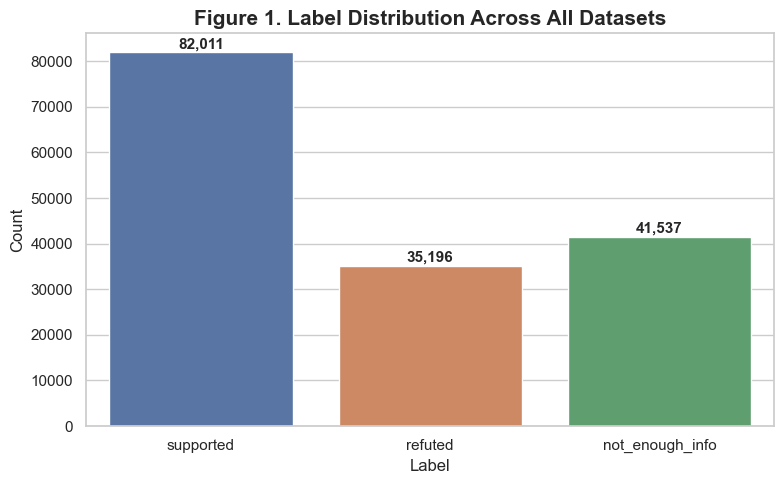

In [20]:
# Use your DataFrame
df = full_df.copy()

# Clean style
sns.set_theme(style="whitegrid")

# Order labels exactly as you used them
label_order = ['supported', 'refuted', 'not_enough_info']

# Count labels
label_counts = df['label'].value_counts().reindex(label_order)

# Create figure
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette=["#4C72B0", "#DD8452", "#55A868"]
)

# Title and labels
plt.title("Figure 1. Label Distribution Across All Datasets", fontsize=15, weight='bold')
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add value labels above bars
for i, v in enumerate(label_counts.values):
    ax.text(i, v + max(label_counts.values)*0.01, f"{v:,}", 
            ha='center', fontsize=11, weight='semibold')

# Clean layout
plt.tight_layout()
plt.show()


C:\Users\djazo\AppData\Local\Temp\ipykernel_32052\4178552982.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


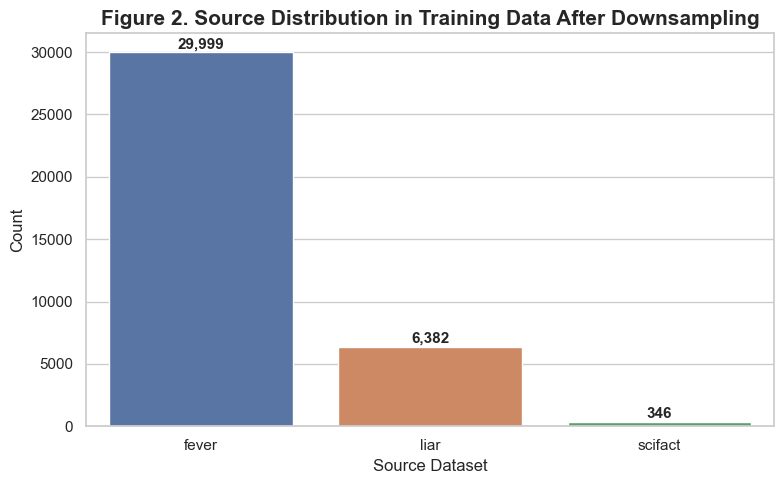

In [31]:

source_order = ['fever', 'liar', 'scifact']
source_counts = train_df['source'].value_counts().reindex(source_order)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=source_counts.index,
    y=source_counts.values,
    palette=["#4C72B0", "#DD8452", "#55A868"]
)

plt.title("Figure 2. Source Distribution in Training Data After Downsampling", fontsize=15, weight='bold')
plt.xlabel("Source Dataset", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add value labels
for i, v in enumerate(source_counts.values):
    ax.text(i, v + max(source_counts.values)*0.01, f"{v:,}",
            ha='center', fontsize=11, weight='semibold')

plt.tight_layout()
plt.show()